In [1]:
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
import os

In [2]:
era5_dir = '/glade/work/addisus/GPM_TOOCAN_data/era5_select'
toocan_dir = '/glade/work/addisus/GPM_TOOCAN_data/gpm_select_toocan/'
toocan_temp_dir = '/glade/work/addisus/GPM_TOOCAN_data/gpm_select_TbExpand'
toocan_precip_dir = '/glade/work/addisus/GPM_TOOCAN_data/gpm_select_CnvStrNorainFlag'

In [3]:
def find_sample(date, dir):
    sample = ""
    for d in os.listdir(dir):
        if date in d:
            sample = d
            print(d)
            break
    return sample

In [4]:
date = '20190704'
sample_era5 = find_sample(date, era5_dir)
sample_toocan = find_sample(date, toocan_dir)
sample_toocan_temp = find_sample(date, toocan_temp_dir)
sample_toocan_precip = find_sample(date, toocan_precip_dir)

20190704.era5_select-toocan-subset_pm6hrsSearch.nc
20190704.gpm_select-toocan-subset.nc
20190704_TbExpand.nc
20190704.CnvStrNorainFlag.nc


In [5]:
era5_path = os.path.join(era5_dir, sample_era5)
toocan_path = os.path.join(toocan_dir, sample_toocan)
toocan_temp_path = os.path.join(toocan_temp_dir, sample_toocan_temp)
toocan_precip_path = os.path.join(toocan_precip_dir, sample_toocan_precip)

In [6]:
era5_ds = xr.open_dataset(era5_path)
toocan_ds = xr.open_dataset(toocan_path)
toocan_temp_ds = xr.open_dataset(toocan_temp_path)
toocan_precip_ds = xr.open_dataset(toocan_precip_path)

## TOOCAN

In [7]:
toocan_ds

<xarray.Dataset> Size: 3MB
Dimensions:         (nt: 48, nc3: 6, nsysmax: 6, nc2: 2, nc1: 3, nlvl: 80)
Coordinates:
  * nc3             (nc3) int32 24B 0 1 2 3 4 5
  * nc2             (nc2) int32 8B -2147483647 -2147483647
  * nc1             (nc1) int32 12B 0 1 2
  * nlvl            (nlvl) float32 320B 0.125 0.375 0.625 ... 19.38 19.62 19.88
Dimensions without coordinates: nt, nsysmax
Data variables: (12/14)
    time            (nt) float32 192B ...
    ndcs            (nt) int32 192B ...
    fnSAT           (nt) |S63 3kB ...
    ngrids          (nc3, nt, nsysmax) int32 7kB ...
    GPMtstampSE     (nc2, nt, nsysmax) |S20 12kB ...
    DCS_number      (nt, nsysmax) int32 1kB ...
    ...              ...
    lc_lat          (nt, nsysmax) float64 2kB ...
    eddyheating     (nc1, nt, nsysmax, nlvl) float64 553kB ...
    eddymoistening  (nc1, nt, nsysmax, nlvl) float64 553kB ...
    swheating       (nc1, nt, nsysmax, nlvl) float64 553kB ...
    lwheating       (nc1, nt, nsysmax, nlvl) float64 553kB ...
    latheating      (nc1, nt, nsysmax, nlvl) float64 553kB ...
Attributes:
    dataset:          Statistics of GPM CSH and rainfall data matched to TOOC...
    source1:          TOOCAN segmented images - Gridded data 0.04 (Thomas Fio...
    source2:          GPM DPR and GMI Convective Stratiform Heating L2 1.5 ho...
    space_coverage:   Northern Hemisphere (-180 to 179.6,39.4N to 0); Souther...
    sample_criteria:  Systems provided here are those overlapped by GPM (with...

### Shortwave and Longwave Heating Profiles

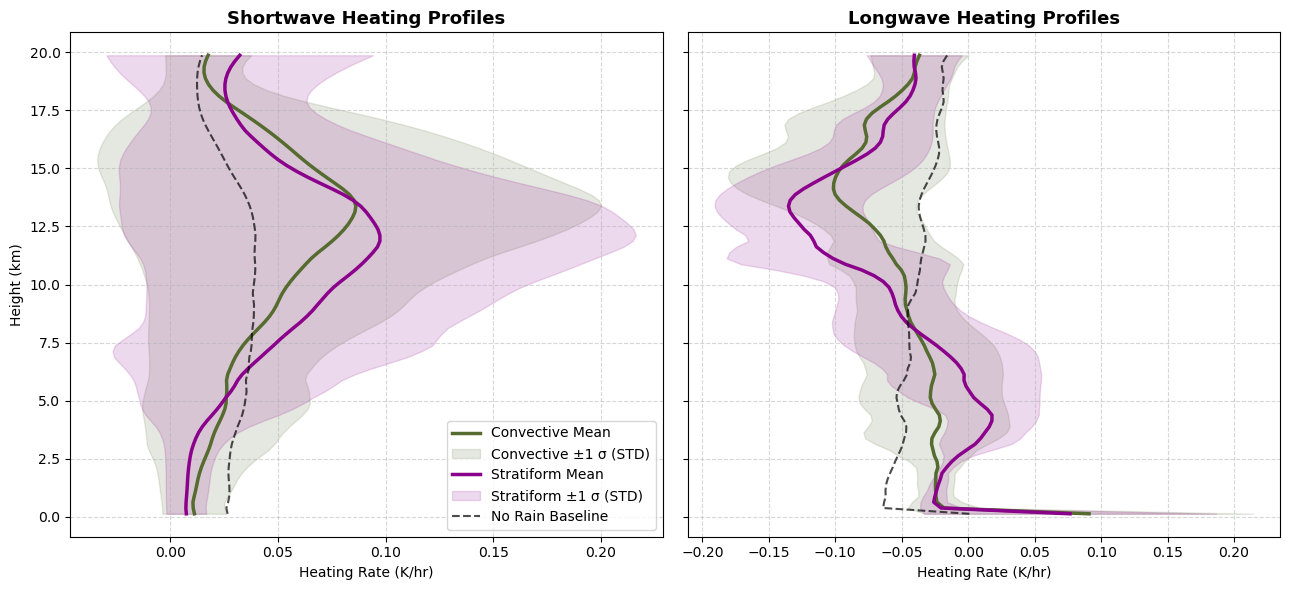

In [8]:
# clean the data
sw = toocan_ds['swheating'].where(toocan_ds['swheating'] > -9000)
lw = toocan_ds['lwheating'].where(toocan_ds['lwheating'] > -9000)

# calculate mean and std for sw heating
mean_sw = sw.mean(dim=['nt', 'nsysmax'])
std_sw = sw.std(dim=['nt', 'nsysmax'])

# calculate mean and std for lw heating
mean_lw = lw.mean(dim=['nt', 'nsysmax'])
std_lw = lw.std(dim=['nt', 'nsysmax'])

# initialize plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 6), sharey=True)
height = toocan_ds['nlvl']

# Shortwave Heating Profile
# convective
ax1.plot(mean_sw.isel(nc1=0), height, label='Convective Mean', color='darkolivegreen', linewidth=2.5)
ax1.fill_betweenx(height, mean_sw.isel(nc1=0) - std_sw.isel(nc1=0), mean_sw.isel(nc1=0) + std_sw.isel(nc1=0), 
                  color='darkolivegreen', alpha=0.15, label='Convective ±1 σ (STD)')

# stratiform
ax1.plot(mean_sw.isel(nc1=1), height, label='Stratiform Mean', color='darkmagenta', linewidth=2.5)
ax1.fill_betweenx(height, mean_sw.isel(nc1=1) - std_sw.isel(nc1=1), mean_sw.isel(nc1=1) + std_sw.isel(nc1=1), 
                  color='darkmagenta', alpha=0.15, label='Stratiform ±1 σ (STD)')
# no rain
ax1.plot(mean_sw.isel(nc1=2), height, label='No Rain Baseline', color='black', linestyle='--', linewidth=1.5, alpha=0.7)

ax1.set_title('Shortwave Heating Profiles', fontsize=13, fontweight='bold')
ax1.set_xlabel('Heating Rate (K/hr)')
ax1.set_ylabel('Height (km)')
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend(fontsize=10, loc='best')

# Longwave Heating
# convective
ax2.plot(mean_lw.isel(nc1=0), height, color='darkolivegreen', linewidth=2.5)
ax2.fill_betweenx(height, mean_lw.isel(nc1=0) - std_lw.isel(nc1=0), mean_lw.isel(nc1=0) + std_lw.isel(nc1=0), color='darkolivegreen', alpha=0.15)

# stratiform
ax2.plot(mean_lw.isel(nc1=1), height, color='darkmagenta', linewidth=2.5)
ax2.fill_betweenx(height, mean_lw.isel(nc1=1) - std_lw.isel(nc1=1), mean_lw.isel(nc1=1) + std_lw.isel(nc1=1), color='darkmagenta', alpha=0.15)
# no rain
ax2.plot(mean_lw.isel(nc1=2), height, color='black', linestyle='--', linewidth=1.5, alpha=0.7)

ax2.set_title('Longwave Heating Profiles', fontsize=13, fontweight='bold')
ax2.set_xlabel('Heating Rate (K/hr)')
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig("toocan_era5_plots/sw_lw_heating_profiles.png", transparent=True)
plt.show()

### Latent Heating Profile

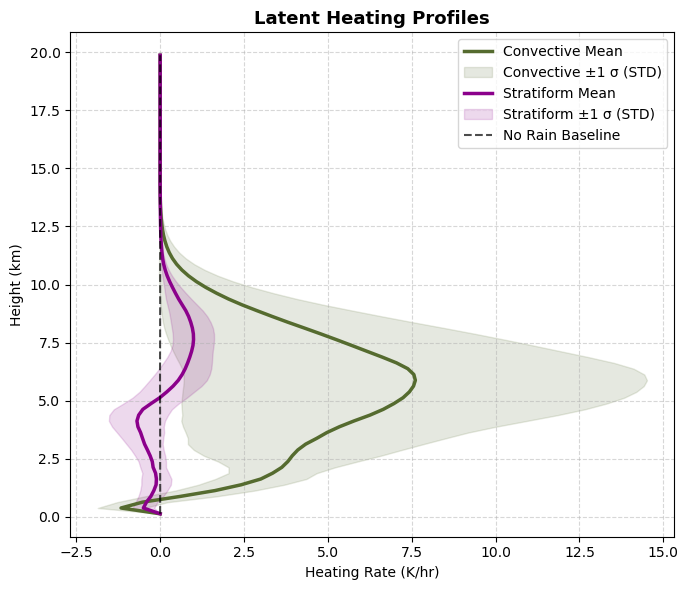

In [9]:
# clean the data
lat = toocan_ds['latheating'].where(toocan_ds['latheating'] > -9000)

# calculate mean and std
mean_lat = lat.mean(dim=['nt', 'nsysmax'])
std_lat = lat.std(dim=['nt', 'nsysmax'])

# intialize plot
fig, ax = plt.subplots(figsize=(7, 6))
height = toocan_ds['nlvl']

# convective
ax.plot(mean_lat.isel(nc1=0), height, label='Convective Mean', color='darkolivegreen', linewidth=2.5)
ax.fill_betweenx(height, mean_lat.isel(nc1=0) - std_lat.isel(nc1=0), mean_lat.isel(nc1=0) + std_lat.isel(nc1=0), 
                 color='darkolivegreen', alpha=0.15, label='Convective ±1 σ (STD)')

# stratiform
ax.plot(mean_lat.isel(nc1=1), height, label='Stratiform Mean', color='darkmagenta', linewidth=2.5)
ax.fill_betweenx(height, mean_lat.isel(nc1=1) - std_lat.isel(nc1=1), mean_lat.isel(nc1=1) + std_lat.isel(nc1=1), 
                 color='darkmagenta', alpha=0.15, label='Stratiform ±1 σ (STD)')

# no rain
ax.plot(mean_lat.isel(nc1=2), height, label='No Rain Baseline', color='black', linestyle='--', linewidth=1.5, alpha=0.7)

ax.set_title('Latent Heating Profiles', fontsize=13, fontweight='bold')
ax.set_xlabel('Heating Rate (K/hr)')
ax.set_ylabel('Height (km)')
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(fontsize=10, loc='best')

plt.tight_layout()
plt.savefig("toocan_era5_plots/lat_heating_profile.png", transparent=True)
plt.show()

### Eddy Profiles

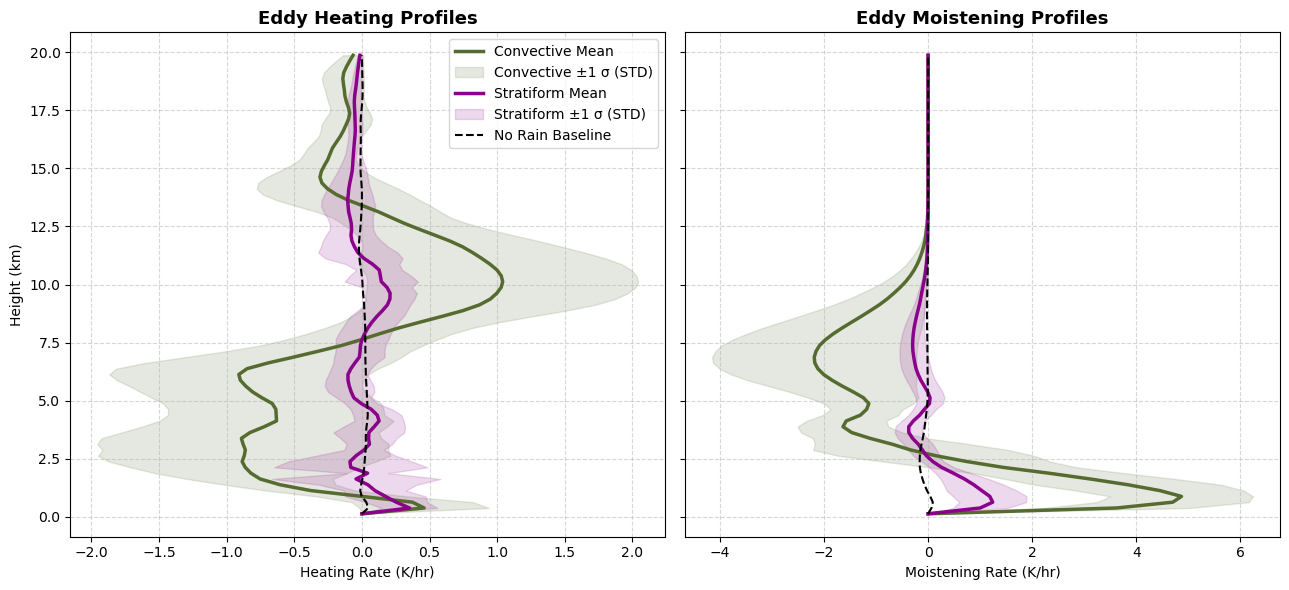

In [10]:
# clean data
eddy_heat = toocan_ds['eddyheating'].where(toocan_ds['eddyheating'] > -9000)
eddy_moist = toocan_ds['eddymoistening'].where(toocan_ds['eddymoistening'] > -9000)

# calculate mean and std eddy_heat
mean_eddy_heat = eddy_heat.mean(dim=['nt', 'nsysmax'])
std_eddy_heat = eddy_heat.std(dim=['nt', 'nsysmax'])

# calculate mean and std eddy_moist
mean_eddy_moist = eddy_moist.mean(dim=['nt', 'nsysmax'])
std_eddy_moist = eddy_moist.std(dim=['nt', 'nsysmax'])

# initialize plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 6), sharey=True)
height = toocan_ds['nlvl']

# Eddy Heating
# convective
ax1.plot(mean_eddy_heat.isel(nc1=0), height, label='Convective Mean', color='darkolivegreen', linewidth=2.5)
ax1.fill_betweenx(height, mean_eddy_heat.isel(nc1=0) - std_eddy_heat.isel(nc1=0), mean_eddy_heat.isel(nc1=0) + std_eddy_heat.isel(nc1=0), 
                  color='darkolivegreen', alpha=0.15, label='Convective ±1 σ (STD)')

# stratiform
ax1.plot(mean_eddy_heat.isel(nc1=1), height, label='Stratiform Mean', color='darkmagenta', linewidth=2.5)
ax1.fill_betweenx(height, mean_eddy_heat.isel(nc1=1) - std_eddy_heat.isel(nc1=1), mean_eddy_heat.isel(nc1=1) + std_eddy_heat.isel(nc1=1), 
                  color='darkmagenta', alpha=0.15, label='Stratiform ±1 σ (STD)')

# no rain
ax1.plot(mean_eddy_heat.isel(nc1=2), height, label='No Rain Baseline', color='black', linestyle='--', linewidth=1.5, alpha=1.0)

ax1.set_title('Eddy Heating Profiles', fontsize=13, fontweight='bold')
ax1.set_xlabel('Heating Rate (K/hr)')
ax1.set_ylabel('Height (km)')
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend(fontsize=10, loc='best')

# Eddy Moistening
# convective
ax2.plot(mean_eddy_moist.isel(nc1=0), height, color='darkolivegreen', linewidth=2.5)
ax2.fill_betweenx(height, mean_eddy_moist.isel(nc1=0) - std_eddy_moist.isel(nc1=0), mean_eddy_moist.isel(nc1=0) + std_eddy_moist.isel(nc1=0), color='darkolivegreen', alpha=0.15)

# stratiform
ax2.plot(mean_eddy_moist.isel(nc1=1), height, color='darkmagenta', linewidth=2.5)
ax2.fill_betweenx(height, mean_eddy_moist.isel(nc1=1) - std_eddy_moist.isel(nc1=1), mean_eddy_moist.isel(nc1=1) + std_eddy_moist.isel(nc1=1), color='darkmagenta', alpha=0.15)

# no rain
ax2.plot(mean_eddy_moist.isel(nc1=2), height, color='black', linestyle='--', linewidth=1.5, alpha=1.0)

ax2.set_title('Eddy Moistening Profiles', fontsize=13, fontweight='bold')
ax2.set_xlabel('Moistening Rate (K/hr)')
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig("toocan_era5_plots/eddy_profiles.png", transparent=True)
plt.show()

### Rainfall Rate CDF

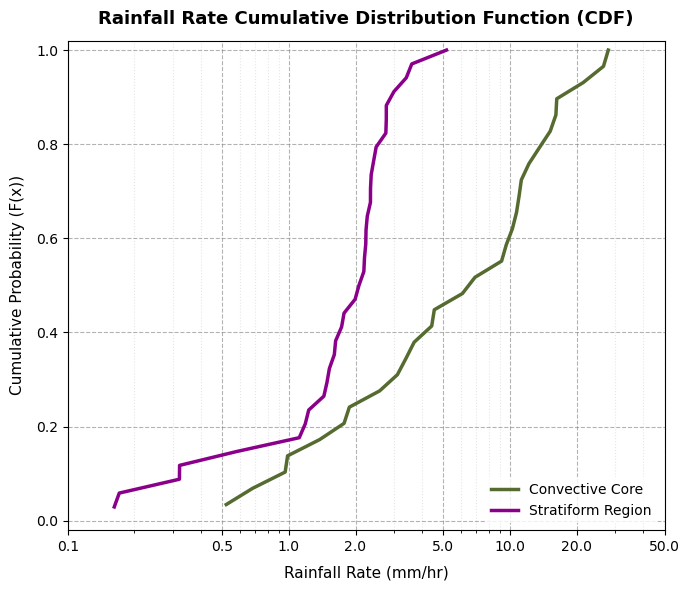

In [11]:
# 1. Mask out missing data placeholders (keep valid rain rates >= 0)
valid_rain = toocan_ds['rainrate'].where((toocan_ds['rainrate'] >= 0) & (toocan_ds['rainrate'] < 500))

# 2. Extract and flatten arrays, dropping NaNs and ignoring completely dry slots (>0)
conv_rain = valid_rain.isel(nc1=0).values.flatten()
conv_rain = conv_rain[~np.isnan(conv_rain) & (conv_rain > 0)]

strat_rain = valid_rain.isel(nc1=1).values.flatten()
strat_rain = strat_rain[~np.isnan(strat_rain) & (strat_rain > 0)]

# 3. Calculate CDFs by sorting the data arrays
conv_sorted = np.sort(conv_rain)
conv_cdf = np.arange(1, len(conv_sorted) + 1) / len(conv_sorted)

strat_sorted = np.sort(strat_rain)
strat_cdf = np.arange(1, len(strat_sorted) + 1) / len(strat_sorted)

# 4. Plotting the CDF spectrum
fig, ax = plt.subplots(figsize=(7, 6))

ax.plot(conv_sorted, conv_cdf, label='Convective Core', color='darkolivegreen', linewidth=2.5)
ax.plot(strat_sorted, strat_cdf, label='Stratiform Region', color='darkmagenta', linewidth=2.5)

# === POLISHED X-AXIS FORMATTING ===
ax.set_xscale('log')
ax.set_xlim(0.1, 50)  # Fits the precise boundaries of your data cleanly

# Clean up log tick marks into standard numbers (0.1, 1, 10) instead of powers of 10
ax.xaxis.set_major_formatter(ScalarFormatter())
ax.set_xticks([0.1, 0.5, 1, 2, 5, 10, 20, 50])  # Explicitly state meaningful rainfall rates

# Double check that labels render as plain decimals/integers
ax.tick_params(axis='x', which='both', labelsize=10)

# Clean up the background grids
ax.grid(True, which="major", linestyle='--', alpha=0.6, color='gray')
ax.grid(True, which="minor", linestyle=':', alpha=0.2, color='gray') # Make minor lines very faint
# ==================================

ax.set_title('Rainfall Rate Cumulative Distribution Function (CDF)', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Rainfall Rate (mm/hr)', fontsize=11, labelpad=8)
ax.set_ylabel('Cumulative Probability (F(x))', fontsize=11, labelpad=8)
ax.set_ylim(-0.02, 1.02)  # Generous padding so lines don't get cut off at 0 or 1
ax.legend(fontsize=10, loc='lower right', frameon=True, facecolor='white', edgecolor='none')

plt.tight_layout()
plt.savefig("toocan_era5_plots/rainfall_rate.png", transparent=True)
plt.show()

## TOOCAN Tb

In [12]:
toocan_temp_ds

<xarray.Dataset> Size: 10GB
Dimensions:     (nlon: 9000, nlat: 2001, nt: 48)
Dimensions without coordinates: nlon, nlat, nt
Data variables:
    lon         (nlon) float32 36kB ...
    lat         (nlat) float32 8kB ...
    time        (nt) float32 192B ...
    DCS_number  (nt, nlat, nlon) float64 7GB ...
    Tb          (nt, nlat, nlon) float32 3GB ...
Attributes:
    dataset:  Brightness Temperature mapped onto TOOCAN grid (30-min, 0.04 de...
    source1:  TOOCAN segmented images - Gridded data 0.04 (Thomas Fiolleau <t...
    source2:  NCEP/CPC 4km Global IR Dataset, 4km-pixel resolution

### Brightness Temperature PDF

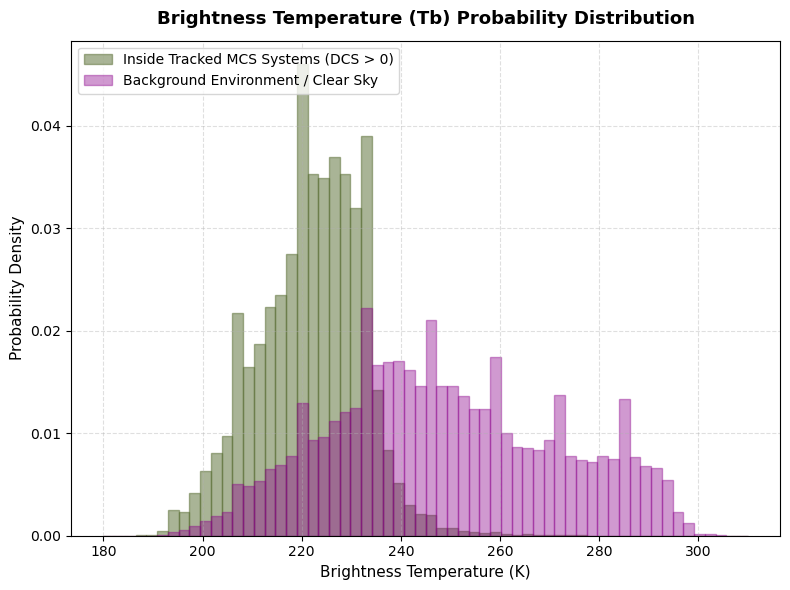

In [13]:
# 1. Isolate tracked vs untracked pixels
# We take a sample of time steps (e.g., every 4th step) to save memory while preserving the true statistical shape
tb_sample = toocan_temp_ds['Tb'].isel(nt=slice(0, None, 4)).values
dcs_sample = toocan_temp_ds['DCS_number'].isel(nt=slice(0, None, 4)).values

# Create flat 1D masks
tracked_mask = (dcs_sample > 0) & (~np.isnan(tb_sample))
background_mask = (dcs_sample == 0) | (np.isnan(dcs_sample)) & (~np.isnan(tb_sample))

tb_tracked = tb_sample[tracked_mask]
tb_background = tb_sample[background_mask]

# To make plotting fast, randomly sub-sample 500,000 points if the array is massive
if len(tb_tracked) > 500000:
    tb_tracked = np.random.choice(tb_tracked, size=500000, replace=False)
if len(tb_background) > 500000:
    tb_background = np.random.choice(tb_background, size=500000, replace=False)

# 2. Plotting the Overlapping Distributions
fig, ax = plt.subplots(figsize=(8, 6))

ax.hist(tb_tracked, bins=60, range=(180, 310), alpha=0.5, color='darkolivegreen', 
        label='Inside Tracked MCS Systems (DCS > 0)', density=True, edgecolor='darkolivegreen')
ax.hist(tb_background, bins=60, range=(180, 310), alpha=0.4, color='darkmagenta', 
        label='Background Environment / Clear Sky', density=True, edgecolor='darkmagenta')

ax.set_title('Brightness Temperature (Tb) Probability Distribution', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Brightness Temperature (K)', fontsize=11)
ax.set_ylabel('Probability Density', fontsize=11)
ax.grid(True, linestyle='--', alpha=0.4)
ax.legend(fontsize=10, loc='upper left')

plt.tight_layout()
plt.savefig("toocan_era5_plots/tb_spatial_pdf.png", transparent=True, dpi=300)
plt.show()

In [14]:
toocan_precip_ds

<xarray.Dataset> Size: 1GB
Dimensions:  (nlon: 9000, nlat: 2001, nt: 18)
Dimensions without coordinates: nlon, nlat, nt
Data variables:
    lon      (nlon) float32 36kB ...
    lat      (nlat) float32 8kB ...
    time     (nt) float32 72B ...
    flag     (nt, nlat, nlon) float32 1GB ...
Attributes:
    dataset:  GPM convective, Stratiform and Norain Type mapped onto TOOCAN g...
    source:   TOOCAN segmented images - Gridded data 0.04 (Thomas Fiolleau <t...

## ERA5

In [15]:
era5_ds

<xarray.Dataset> Size: 1MB
Dimensions:     (nt: 48, nc3: 3, nsysmax: 6, nc2: 3, nc1: 4, nlvl: 15)
Coordinates:
  * nc3         (nc3) int32 12B 0 1 2
  * nc2         (nc2) int32 12B 0 1 2
  * nc1         (nc1) int32 16B 0 1 2 3
Dimensions without coordinates: nt, nsysmax, nlvl
Data variables: (12/13)
    time        (nt) float32 192B ...
    ndcs        (nt) int32 192B ...
    ngrids      (nc3, nt, nsysmax) int32 3kB ...
    DCS_number  (nt, nsysmax) int32 1kB ...
    deltatime   (nc2, nt) float64 1kB ...
    lc_lon      (nt, nsysmax) float64 2kB ...
    ...          ...
    CAPE        (nc2, nc1, nt, nsysmax) float64 28kB ...
    uprof       (nc2, nt, nsysmax, nlvl) float64 104kB ...
    vprof       (nc2, nt, nsysmax, nlvl) float64 104kB ...
    tprof       (nc2, nc1, nt, nsysmax, nlvl) float64 415kB ...
    qprof       (nc2, nc1, nt, nsysmax, nlvl) float64 415kB ...
    plev        (nc2, nc1, nt, nsysmax, nlvl) float64 415kB ...
Attributes:
    dataset:            Statistics of ERA5 data matched to TOOCAN Tracked (30...
    source1:            TOOCAN segmented images - Gridded data 0.04 (Thomas F...
    source2:            ERA5: 6-hourly reanalysis data on surface and pressur...
    space_coverage:     Northern Hemisphere (-180 to 179.6,39.4N to 0); South...
    mapping_algorithm:  System is expanded 0.24 degree outward (6 extra TOOCA...
    sample_criteria:    Systems provided here are those already covered by GPM

In [16]:
import numpy as np
import xarray as xr


def build_convective_master_dataset(toocan_temp_ds, toocan_precip_ds, era5_ds):
    print("--- Initializing Master Dataset Compilation Pipeline ---")

    # =========================================================================
    # STEP 1: ALIGN THE SPATIAL BASE GRIDS (TOOCAN TEMP & GPM PRECIP)
    # =========================================================================
    # Your precip dataset has 18 timesteps; your temp grid might have 48.
    # We will use the spatial layout and time steps of toocan_temp_ds as our master frame.
    master_time = toocan_temp_ds["time"].values
    master_lat = toocan_temp_ds["nlat"].values
    master_lon = toocan_temp_ds["nlon"].values

    print(
        f"Master Shape Set: Time={len(master_time)}, Lat={len(master_lat)}, Lon={len(master_lon)}"
    )

    # Clean missing flags from the base satellite layers
    tb_master = toocan_temp_ds["Tb"].values
    dcs_master = toocan_temp_ds["DCS_number"].values

    # Interp/Align precipitation grid onto the exact master grid boundaries
    print("Aligning GPM precipitation layers onto master grid coordinates...")
    precip_aligned = toocan_precip_ds.reindex(
        nt=toocan_temp_ds.nt, method="nearest"
    )  # Aligns times safely
    # If spatial dimensions differ slightly, use xarray's interp:
    # precip_aligned = toocan_precip_ds.interp(nlat=master_lat, nlon=master_lon, method='nearest')

    # Extract flag variable: {1}GPM_cnv, {2}GPM_noncnv, {3}GPM_norain, {4}GPM_missing
    precip_flag = precip_aligned["flag"].values

    # =========================================================================
    # STEP 2: INITIALIZE BROADCAST ARRAYS FOR SYSTEM-SCALE METRICS
    # =========================================================================
    # Create empty, NaN-filled 3D arrays matching the full spatial map (nt, nlat, nlon)
    shape_3d = (len(master_time), len(master_lat), len(master_lon))

    master_cape = np.full(shape_3d, np.nan, dtype=np.float32)
    master_uprof_850 = np.full(
        shape_3d, np.nan, dtype=np.float32
    )  # Lower steering layer
    master_vprof_850 = np.full(shape_3d, np.nan, dtype=np.float32)
    master_qprof_surface = np.full(
        shape_3d, np.nan, dtype=np.float32
    )  # Surface boundary moisture

    # Extract raw ERA5 arrays for spatial distribution
    era5_cape = era5_ds["CAPE"].values
    era5_uprof = era5_ds["uprof"].values
    era5_vprof = era5_ds["vprof"].values
    era5_qprof = era5_ds["qprof"].values
    era5_dcs_slots = era5_ds["DCS_number"].values

    # Clean out ERA5 -9999 artifacts instantly
    era5_cape[era5_cape <= -9000] = np.nan
    era5_uprof[era5_uprof <= -9000] = np.nan
    era5_vprof[era5_vprof <= -9000] = np.nan
    era5_qprof[era5_qprof <= -9000] = np.nan

    # =========================================================================
    # STEP 3: MAP ENVIRONMENT TO PIXELS USING ACTIVE STORM IDENTIFIERS
    # =========================================================================
    print("Broadcasting ERA5 vertical slices onto spatial map pixels...")

    # Loop through the 48 half-hour windows
    for t_idx in range(len(master_time)):
        # Isolate the 2D storm footprint map at this specific half-hour
        spatial_dcs_slice = dcs_master[t_idx, :, :]

        # Look across the 6 available tracking slots in ERA5
        for s_idx in range(6):
            slot_storm_id = era5_dcs_slots[t_idx, s_idx]

            # If a slot contains an active storm ID (> 0), find its pixels on the map
            if slot_storm_id > 0 and not np.isnan(slot_storm_id):
                pixel_mask = spatial_dcs_slice == slot_storm_id

                if np.any(pixel_mask):
                    # 1. Extract CAPE (Core zone nc2=0, metric nc1=0)
                    master_cape[t_idx, pixel_mask] = era5_cape[
                        0, 0, t_idx, s_idx
                    ]

                    # 2. Extract surface level boundary layer moisture (nlvl=0 is typically surface)
                    master_qprof_surface[t_idx, pixel_mask] = era5_qprof[
                        0, 0, t_idx, s_idx, 0
                    ]

                    # 3. Extract 850 hPa low-level wind vectors (e.g., nlvl=3 depending on index map)
                    master_uprof_850[t_idx, pixel_mask] = era5_uprof[
                        0, t_idx, s_idx, 3
                    ]
                    master_vprof_850[t_idx, pixel_mask] = era5_vprof[
                        0, t_idx, s_idx, 3
                    ]

    # =========================================================================
    # STEP 4: ASSEMBLE XARRAY MASTER DATASET
    # =========================================================================
    print("Assembling unified master Xarray infrastructure...")

    master_ds = xr.Dataset(
        data_vars=dict(
            # TOOCAN satellite parameters
            Tb=(["time", "nlat", "nlon"], tb_master),
            DCS_number=(["time", "nlat", "nlon"], dcs_master),
            # GPM precipitation ground truth flag
            rain_flag=(["time", "nlat", "nlon"], precip_flag),
            # Spatialized ERA5 thermodynamic inputs (Perfect for ML models)
            environmental_CAPE=(["time", "nlat", "nlon"], master_cape),
            surface_humidity=(["time", "nlat", "nlon"], master_qprof_surface),
            steering_wind_u=(["time", "nlat", "nlon"], master_uprof_850),
            steering_wind_v=(["time", "nlat", "nlon"], master_vprof_850),
        ),
        coords=dict(
            time=master_time,
            nlat=master_lat,
            nlon=master_lon,
        ),
        attrs=dict(
            description="Master pixel-level dataset combining TOOCAN, GPM, and ERA5 spatial fields."
        ),
    )

    print("--- Master Dataset Compiled Successfully! ---")
    return master_ds

In [17]:
master_dataset = build_convective_master_dataset(toocan_temp_ds, tooocan_precip_ds, era5_ds)
print(master_dataset)

NameError: name 'tooocan_precip_ds' is not defined

In [ ]:
era5_ds

In [ ]:
toocan_ds

In [ ]:
toocan_temp_ds

In [ ]:
toocan_precip_ds

In [ ]:
def build_unified_convective_master(
    toocan_temp_ds, toocan_precip_ds, era5_ds, toocan_ds
):
    print("--- Beginning Master Dataset Compilation Pipeline ---")

    # =========================================================================
    # STEP 1: DEFINE THE MASTER TEMPORAL AND SPATIAL COORDINATES
    # =========================================================================
    # Standardize names to match your dataset keys exactly
    master_time = toocan_temp_ds["time"].values  # 48 steps
    master_lat = toocan_temp_ds["lat"].values  # 2001 elements
    master_lon = toocan_temp_ds["lon"].values  # 9000 elements

    shape_3d = (len(master_time), len(master_lat), len(master_lon))
    print(f"Master Matrix Footprint Initialized: {shape_3d}")

    # Pull the core tracking matrices from the temperature dataset
    tb_array = toocan_temp_ds["Tb"].values
    dcs_array = toocan_temp_ds["DCS_number"].values

    # =========================================================================
    # STEP 2: TIME-ALIGN THE GPM RAINFALL FLAGS
    # =========================================================================
    print("Aligning GPM Precipitation timeline to master clock...")
    # Reindexing handles the step from 18 to 48 time increments smoothly
    precip_aligned = toocan_precip_ds.reindex(time=master_time, method="nearest")
    rain_flag_array = precip_aligned["flag"].values

    # =========================================================================
    # STEP 3: INITIALIZE PIXEL BROADCAST MATRICES FOR ERA5 & TOOCAN
    # =========================================================================
    # ERA5 Environmental parameters
    master_cape = np.full(shape_3d, np.nan, dtype=np.float32)
    master_qprof_surface = np.full(shape_3d, np.nan, dtype=np.float32)

    # TOOCAN Convective Core trackers
    master_rainrate = np.full(shape_3d, np.nan, dtype=np.float32)
    master_latent_heating = np.full(
        shape_3d, np.nan, dtype=np.float32
    )  # Pulling mid-level latent heating

    # Extract raw tracking vectors
    era5_dcs_slots = era5_ds["DCS_number"].values
    era5_cape = era5_ds["CAPE"].values
    era5_qprof = era5_ds["qprof"].values

    toocan_dcs_slots = toocan_ds["DCS_number"].values
    toocan_rainrate = toocan_ds["rainrate"].values
    toocan_latheating = toocan_ds["latheating"].values

    # Automatically clean out any -9999 or negative artifact flags
    era5_cape[era5_cape <= -9000] = np.nan
    era5_qprof[era5_qprof <= -9000] = np.nan
    toocan_rainrate[toocan_rainrate <= -9000] = np.nan
    toocan_latheating[toocan_latheating <= -9000] = np.nan

    # =========================================================================
    # STEP 4: SPATIAL MAP LOOP
    # =========================================================================
    print("Mapping tracking profiles to pixel coordinates...")

    for t_idx in range(len(master_time)):
        spatial_dcs_slice = dcs_array[t_idx, :, :]

        # Look through the 6 active storm tracking slots
        for s_idx in range(6):
            # Find which storm ID owns this tracking slot at this half-hour
            era5_id = era5_dcs_slots[t_idx, s_idx]
            toocan_id = toocan_dcs_slots[t_idx, s_idx]

            # Process ERA5 variables if the slot is active
            if era5_id > 0 and not np.isnan(era5_id):
                pixel_mask = spatial_dcs_slice == era5_id

                if np.any(pixel_mask):
                    # Map CAPE (nc2=0, nc1=0)
                    master_cape[t_idx, pixel_mask] = era5_cape[
                        0, 0, t_idx, s_idx
                    ]
                    # Map Specific Humidity (nlvl=0 for surface boundary layer)
                    master_qprof_surface[t_idx, pixel_mask] = era5_qprof[
                        0, 0, t_idx, s_idx, 0
                    ]

            # Process TOOCAN core variables if the slot is active
            if toocan_id > 0 and not np.isnan(toocan_id):
                pixel_mask = spatial_dcs_slice == toocan_id

                if np.any(pixel_mask):
                    # Map Rainrate (nc1=0)
                    master_rainrate[t_idx, pixel_mask] = toocan_rainrate[
                        0, t_idx, s_idx
                    ]
                    # Map Latent Heating at mid-cloud level (e.g., nlvl=40)
                    master_latent_heating[t_idx, pixel_mask] = (
                        toocan_latheating[0, t_idx, s_idx, 40]
                    )

    # =========================================================================
    # STEP 5: ASSEMBLE MASTER DATASET
    # =========================================================================
    print("Compiling final consolidated master object structure...")

    master_ds = xr.Dataset(
        data_vars=dict(
            # Core Fields
            Tb=(["time", "lat", "lon"], tb_array),
            DCS_number=(["time", "lat", "lon"], dcs_array),
            rain_flag=(["time", "lat", "lon"], rain_flag_array),
            # Spatialized ERA5 Environment Features
            environmental_CAPE=(["time", "lat", "lon"], master_cape),
            surface_humidity=(["time", "lat", "lon"], master_qprof_surface),
            # Spatialized TOOCAN System Structural Features
            system_rainrate=(["time", "lat", "lon"], master_rainrate),
            midlevel_latent_heating=(["time", "lat", "lon"], master_latent_heating),
        ),
        coords=dict(
            time=master_time,
            lat=master_lat,
            lon=master_lon,
        ),
        attrs=dict(
            description="Master Unified Pixel Dataset for Convective Initiation Modeling."
        ),
    )

    print("--- Master Dataset Compiled Successfully! ---")
    return master_ds

In [ ]:
master_dataset = build_unified_convective_master(toocan_temp_ds, toocan_precip_ds, era5_ds, toocan_ds)

In [ ]:
def build_unified_master_low_memory(
    toocan_temp_ds, toocan_precip_ds, era5_ds, toocan_ds, output_filename="master_convective_dataset.nc"
):
    print("--- Beginning Low-Memory Master Dataset Compilation Pipeline ---")

    # 1. Establish the target master coordinates
    master_nt = toocan_temp_ds["nt"].values           # Indices: 0 to 47
    master_lat = toocan_temp_ds["lat"].values         # 2001 elements
    master_lon = toocan_temp_ds["lon"].values         # 9000 elements
    
    # Extract the pure numpy arrays for the physical hours (e.g., 0.0, 0.5, 1.0...)
    master_time_vals = toocan_temp_ds["time"].values  # 48 elements
    precip_time_vals = toocan_precip_ds["time"].values # 18 elements

    # Extract tracking vectors from storm-centric tracking files
    era5_dcs_slots = era5_ds["DCS_number"].values
    era5_cape = era5_ds["CAPE"].values
    era5_qprof = era5_ds["qprof"].values

    toocan_dcs_slots = toocan_ds["DCS_number"].values
    toocan_rainrate = toocan_ds["rainrate"].values
    toocan_latheating = toocan_ds["latheating"].values

    # Clean out negative tracking artifacts (-9999) from matrices
    era5_cape[era5_cape <= -9000] = np.nan
    era5_qprof[era5_qprof <= -9000] = np.nan
    toocan_rainrate[toocan_rainrate <= -9000] = np.nan
    toocan_latheating[toocan_latheating <= -9000] = np.nan

    # Clear old file if it already exists to avoid file corruptions or append errors
    if os.path.exists(output_filename):
        os.remove(output_filename)

    # 2. Process each half-hour step sequentially to save RAM
    print("Processing spatial grids step-by-step and streaming to disk...")
    for t_idx in range(len(master_nt)):
        current_nt = master_nt[t_idx]
        current_time_val = master_time_vals[t_idx]

        # Pure NumPy nearest-neighbor time alignment for precipitation grid
        closest_precip_idx = np.abs(precip_time_vals - current_time_val).argmin()

        # Isolate 2D spatial slices for just this specific index
        tb_slice = toocan_temp_ds["Tb"].isel(nt=t_idx).values
        dcs_slice = toocan_temp_ds["DCS_number"].isel(nt=t_idx).values
        rain_flag_slice = toocan_precip_ds["flag"].isel(nt=closest_precip_idx).values

        # Initialize empty 2D matrices for environmental/core variables
        shape_2d = (len(master_lat), len(master_lon))
        cape_2d = np.full(shape_2d, np.nan, dtype=np.float32)
        qprof_2d = np.full(shape_2d, np.nan, dtype=np.float32)
        rainrate_2d = np.full(shape_2d, np.nan, dtype=np.float32)
        latheating_2d = np.full(shape_2d, np.nan, dtype=np.float32)

        # Scan the 6 active storm tracking slots for this specific time step
        for s_idx in range(6):
            era5_id = era5_dcs_slots[t_idx, s_idx]
            toocan_id = toocan_dcs_slots[t_idx, s_idx]

            # Map ERA5 variables to matching pixels using active storm IDs
            if era5_id > 0 and not np.isnan(era5_id):
                pixel_mask = dcs_slice == era5_id
                if np.any(pixel_mask):
                    cape_2d[pixel_mask] = era5_cape[0, 0, t_idx, s_idx]
                    qprof_2d[pixel_mask] = era5_qprof[0, 0, t_idx, s_idx, 0]

            # Map TOOCAN Core tracking variables to matching pixels using active storm IDs
            if toocan_id > 0 and not np.isnan(toocan_id):
                pixel_mask = dcs_slice == toocan_id
                if np.any(pixel_mask):
                    rainrate_2d[pixel_mask] = toocan_rainrate[0, t_idx, s_idx]
                    latheating_2d[pixel_mask] = toocan_latheating[0, t_idx, s_idx, 40]

        # 3. Pack this single time slice into a temporary xarray dataset
        slice_ds = xr.Dataset(
            data_vars=dict(
                Tb=(["lat", "lon"], tb_slice),
                DCS_number=(["lat", "lon"], dcs_slice),
                rain_flag=(["lat", "lon"], rain_flag_slice),
                environmental_CAPE=(["lat", "lon"], cape_2d),
                surface_humidity=(["lat", "lon"], qprof_2d),
                system_rainrate=(["lat", "lon"], rainrate_2d),
                midlevel_latent_heating=(["lat", "lon"], latheating_2d),
                time=(current_time_val), 
            ),
            coords=dict(
                nt=current_nt,  
                lat=master_lat,
                lon=master_lon,
            ),
        )

        # Expand the dimension back out so xarray knows it belongs in a timeline series
        slice_ds = slice_ds.expand_dims("nt")

        # 4. Stream write directly to disk netCDF format using correct unlimited_dims syntax
        if t_idx == 0:
            # First slice: define 'nt' as an unlimited/growable dimension on disk
            slice_ds.to_netcdf(output_filename, mode="w", unlimited_dims=["nt"]) 
        else:
            # Subsequent slices: append along the existing file structure
            slice_ds.to_netcdf(output_filename, mode="a") 

        if (t_idx + 1) % 4 == 0 or (t_idx + 1) == len(master_nt):
            print(f"   Progress: Time step {t_idx+1}/{len(master_nt)} saved to disk.")

    print(f"\n--- Master Dataset Compiled and Saved Successfully: '{output_filename}' ---")

    # Open and return the dataset handle lazily
    return xr.open_dataset(output_filename)

In [ ]:
master_dataset = build_unified_master_low_memory(toocan_temp_ds, toocan_precip_ds, era5_ds, toocan_ds)

In [ ]:
print(era5_ds["CAPE"])

In [ ]:
master_ds = xr.open_dataset("master_convective_dataset.nc")
master_ds

In [ ]:
# =========================================================================
# 1. DYNAMIC ZONE FINDER: Find where a storm actually exists at nt=0
# =========================================================================
# Isolate the tracking mask layer for the first time step
dcs_layer = master_dataset["DCS_number"].isel(nt=0)

# Find coordinates where DCS_number is greater than 0
active_storm_indices = np.argwhere(dcs_layer.values > 0)

if len(active_storm_indices) == 0:
    print("⚠️ Warning: No active TOOCAN storms found at nt=0! Try changing .isel(nt=0) to a different time index step.")
else:
    # Extract the lat/lon coordinate arrays
    lat_vals = master_dataset["lat"].values
    lon_vals = master_dataset["lon"].values
    
    # Get the bounding boundaries of the active storm area
    min_lat_idx, min_lon_idx = active_storm_indices.min(axis=0)
    max_lat_idx, max_lon_idx = active_storm_indices.max(axis=0)
    
    # Pad the bounding box slightly so we can see the surroundings of the storm
    pad = 30  # Adjust padding size if you want to zoom out further
    lat_start = lat_vals[max(0, min_lat_idx - pad)]
    lat_end = lat_vals[min(len(lat_vals)-1, max_lat_idx + pad)]
    lon_start = lon_vals[max(0, min_lon_idx - pad)]
    lon_end = lon_vals[min(len(lon_vals)-1, max_lon_idx + pad)]
    
    print(f"🎯 Found active storm tracks! Auto-zooming map coordinates to:")
    print(f"   Latitude: Bounds ({lat_start:.2f} to {lat_end:.2f})")
    print(f"   Longitude: Bounds ({lon_start:.2f} to {lon_end:.2f})")

    # Slice out our focused storm sector box
    # Using min/max logic inside slice to handle ascending or descending index directions automatically
    sample_slice = master_dataset.isel(nt=0).sel(
        lat=slice(max(lat_start, lat_end), min(lat_start, lat_end)), 
        lon=slice(min(lon_start, lon_end), max(lon_start, lon_end))
    )

    # =========================================================================
    # 2. RENDER MULTI-PANEL DIAGNOSTIC VISUALIZATION
    # =========================================================================
    fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=True, sharey=True)
    fig.suptitle("Convective Master Dataset Co-Location Audit (Auto-Zoomed)", fontsize=16, weight='bold')

    # Panel A: Cloud Top Brightness Temperatures
    im1 = axes[0, 0].pcolormesh(sample_slice.lon, sample_slice.lat, sample_slice.Tb, cmap="inferno_r", shading='auto')
    axes[0, 0].set_title("A) Brightness Temp (Tb) [Cold Cloud Tops]")
    fig.colorbar(im1, ax=axes[0, 0], label="Kelvin")

    # Panel B: Storm Tracking Mask System Geometries
    im2 = axes[0, 1].pcolormesh(sample_slice.lon, sample_slice.lat, sample_slice.DCS_number, cmap="tab20", shading='auto')
    axes[0, 1].set_title("B) TOOCAN System Identifiers (DCS_number)")
    fig.colorbar(im2, ax=axes[0, 1], label="Storm Track ID")

    # Panel C: Mapped Convective Structural Rainrates
    im3 = axes[1, 0].pcolormesh(sample_slice.lon, sample_slice.lat, sample_slice.system_rainrate, cmap="Blues", shading='auto')
    axes[1, 0].set_title("C) Mapped System Rainrate")
    fig.colorbar(im3, ax=axes[1, 0], label="mm/hr")

    # Panel D: Spatialized Environmental Thermodynamics
    im4 = axes[1, 1].pcolormesh(sample_slice.lon, sample_slice.lat, sample_slice.environmental_CAPE, cmap="YlOrRd", shading='auto')
    axes[1, 1].set_title("D) Spatialized Environmental CAPE")
    fig.colorbar(im4, ax=axes[1, 1], label="J/kg")

    for ax in axes.flat:
        ax.set_ylabel("Latitude")
        ax.set_xlabel("Longitude")

    plt.tight_layout()
    plt.show()

In [ ]:
import seaborn as sns
import pandas as pd

# Flatten the spatial grids into a 1D pandas frame for data variables inside active storm zones
df_sample = master_dataset.isel(nt=0).to_dataframe().reset_index()
df_storms = df_sample[df_sample["DCS_number"] > 0].dropna(subset=["midlevel_latent_heating", "Tb"])

plt.figure(figsize=(10, 6))
# Hexbin shows density tracking without over-plotting thousands of grid points
plt.hexbin(df_storms['Tb'], df_storms['midlevel_latent_heating'], gridsize=40, cmap='viridis', mincnt=1)

plt.title("Physical Consistency Check: Midlevel Latent Heating vs. Cloud Top Temperature")
plt.xlabel("Brightness Temperature (Tb) [K]")
plt.ylabel("Midlevel Latent Heating")
plt.grid(True, linestyle="--", alpha=0.5)
plt.colorbar(label='Pixel Density Count')

plt.show()

### Positive CAPE != Convection

In [ ]:
# 1. Determine if ANY rain exists at each time step (Collapses spatial dims)
# .any(dim=['nlat', 'nlon']) results in a 1D array of True/False values for each time step
rain_exists_per_step = (toocan_precip_ds["flag"] == 1).any(dim=['nlat', 'nlon'])

# 2. Filter the time coordinates based on that boolean array
# This gives you a 1D list of UNIQUE time steps where rain occurred
flag_times = toocan_precip_ds["time"].where(rain_exists_per_step, drop=True).values

# 3. Plot ERA5 CAPE
ax = plt.gca()
era5_ds.where(era5_ds != -9999).plot.scatter(
    x="time", y="CAPE", color="darkmagenta", label="ERA5 CAPE", alpha=0.6, ax=ax
)

# 4. Plot unique lines
ymin, ymax = ax.get_ylim()
ax.vlines(x=flag_times, ymin=ymin, ymax=ymax, color="darkolivegreen", 
          alpha=1, linestyle="--", label="TOOCAN Convective Flag")

ax.set_title("ERA5 CAPE with TOOCAN Convective Flags")
plt.legend()
plt.tight_layout()
plt.savefig("toocan_era5_plots/ERA5_CAPE_with_TOOCAN_Flags.png", transparent = True, dpi=300)
plt.show()